# Assignment

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Create a notebook that does some simple EDA on some data.

This code finds the file path of the project root folder.

In [2]:
def find_project_root(start: Path = Path.cwd()) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists() or (path / ".git").exists():
            return path
    raise FileNotFoundError("Could not find project root.")

ROOT = find_project_root()
DATA = ROOT / "data"

In [3]:
df = pd.read_csv(DATA / "sales.csv")

In [4]:
df

,net_sales,sq_ft,inventory,advertising,district_size,competing_stores
0,231.0,3.0,294,8.2,8.200000,11
1,156.0,2.2,232,6.9,4.100000,12
2,10.0,0.5,149,3.0,4.300000,15
3,519.0,5.5,600,12.0,16.100000,1
4,437.0,4.4,567,10.6,14.100000,5
5,487.0,4.8,571,11.8,12.700000,4
6,299.0,3.1,512,8.1,10.100000,10
7,195.0,2.5,347,7.7,8.400000,12
8,20.0,1.2,212,3.3,2.100000,15
9,68.0,0.6,102,4.9,4.700000,8


Text(0, 0.5, 'Net Sales')

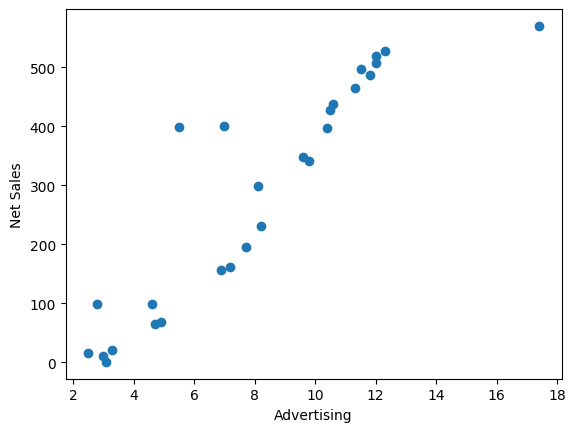

In [5]:
fix, ax = plt.subplots()

ax.scatter(df["advertising"], df["net_sales"])
ax.set_xlabel("Advertising")
ax.set_ylabel("Net Sales")

## 2. Create a script to download the CDC dataset

In [6]:
import requests
import shutil
import os
import re
import gzip

def download(year, spath):

    # Download the zip archive
    url_pat = "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Datasets/DVS/natality/"
    url = f"{url_pat}/Nat{year}.zip"
    response = requests.get(url)
    target = spath / f"Nat{year}.zip"
    open(target, "wb").write(response.content)

    # Unpack the zip archive and remove the archive file
    shutil.unpack_archive(target, spath)
    target.unlink()

    # Gzip the data file
    # NOTE: casing of the raw fwf filenames is irregular, they
    # seem to end in 'pub', 'txt', or have no extension.
    fnames = os.listdir(spath)
    r = re.compile(str(year) + "(.pub|.txt|)$", re.IGNORECASE)
    fnames = [f for f in fnames if r.search(f)]
    assert len(fnames) == 1
    fname = fnames[0]
    source = spath / fname
    target = spath / f"Natl{year}.pub.gz"
    with open(source, "rb") as fin:
        with gzip.open(target, "wb") as fout:
            shutil.copyfileobj(fin, fout)
    source.unlink()